Rainfall Prediction using Decision Tree
Mini Project based on paper: Machine Learning-Based Rainfall Prediction

Dataset: Australian Rainfall Dataset
Algorithm: Decision Tree
Feature Selection: Correlation + Feature Ranking

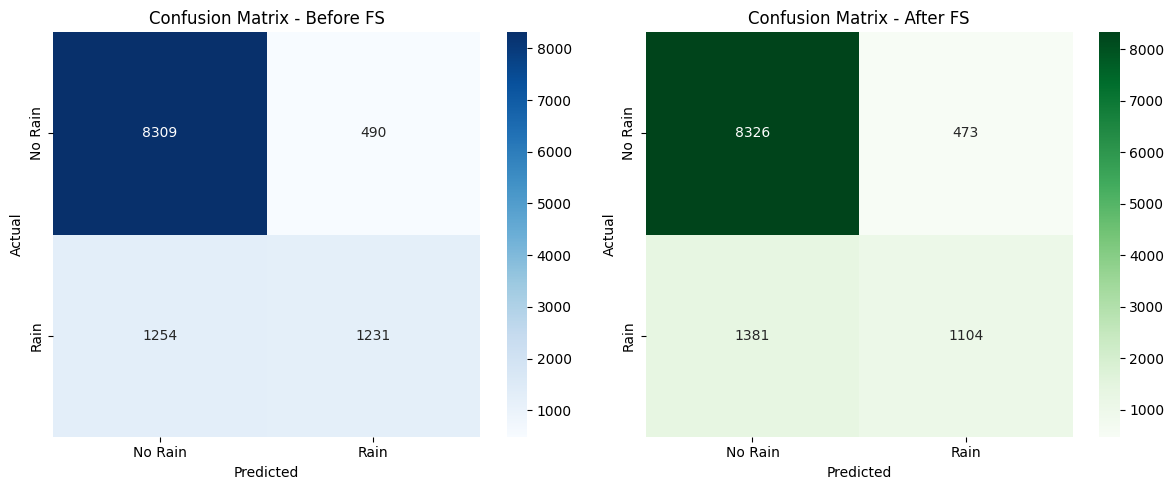

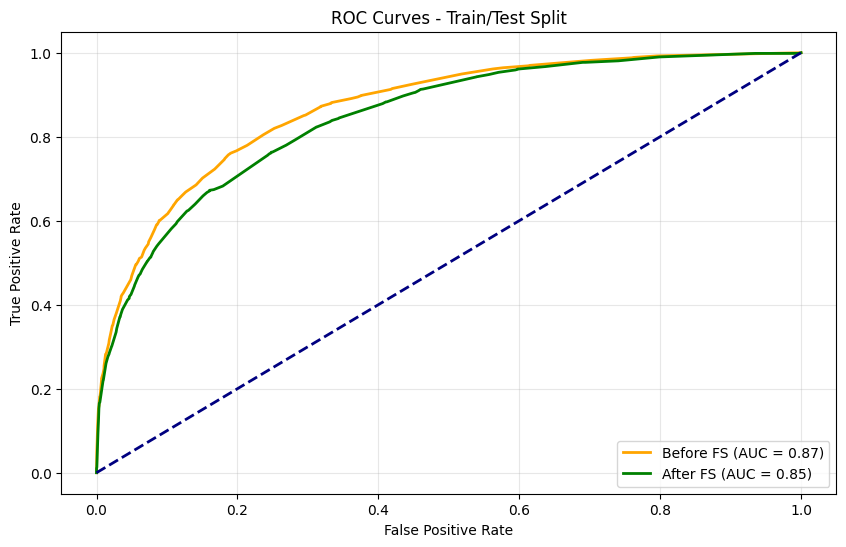

In [2]:

# CONFUSION MATRICES AND ROC CURVES

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

#  Confusion Matrices
cm_before = confusion_matrix(y_test_before, y_pred_before)
cm_after = confusion_matrix(y_test_after, y_pred_after)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before Feature Selection
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
axes[0].set_title('Confusion Matrix - Before FS')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# After Feature Selection
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
axes[1].set_title('Confusion Matrix - After FS')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ----- ROC Curves -----
y_pred_proba_before = dt_before.predict_proba(X_test_before)[:, 1]
y_pred_proba_after = dt_after.predict_proba(X_test_after)[:, 1]

fpr_before, tpr_before, _ = roc_curve(y_test_before, y_pred_proba_before)
fpr_after, tpr_after, _ = roc_curve(y_test_after, y_pred_proba_after)

roc_auc_before = roc_auc_score(y_test_before, y_pred_proba_before)
roc_auc_after = roc_auc_score(y_test_after, y_pred_proba_after)

plt.figure(figsize=(10, 6))
plt.plot(fpr_before, tpr_before, label=f'Before FS (AUC = {roc_auc_before:.2f})', color='orange', lw=2)
plt.plot(fpr_after, tpr_after, label=f'After FS (AUC = {roc_auc_after:.2f})', color='green', lw=2)
plt.plot([0, 1], [0, 1], '--', color='navy', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Train/Test Split')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [1]:
# ============================================
# IMPORT LIBRARIES
# ============================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, QuantileTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')


np.random.seed(42)


# LOAD DATA

df = pd.read_csv(r"C:\Rainproj\rain.csv")  


# PREPROCESSING


if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Month'] = df['Date'].dt.month
    df.drop('Date', axis=1, inplace=True)


df.dropna(inplace=True)  

categorical_cols = df.select_dtypes(include=['object','string']).columns
categorical_cols = [c for c in categorical_cols if c not in ['RainToday','RainTomorrow']]

for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))


df['RainToday'] = LabelEncoder().fit_transform(df['RainToday'].astype(str))
df['RainTomorrow'] = LabelEncoder().fit_transform(df['RainTomorrow'].astype(str))


qt = QuantileTransformer(output_distribution='normal')
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('RainTomorrow')  
df[numerical_cols] = qt.fit_transform(df[numerical_cols])


# FEATURE SELECTION

top_features =  ['Humidity3pm', 'Sunshine', 'Humidity9am', 'Rainfall', 'Cloud9am','Cloud3pm','RainToday']



X_before = df.drop('RainTomorrow', axis=1)
X_after = df[top_features]
y = df['RainTomorrow']

print("\nDataset shapes:")
print("Before FS:", X_before.shape)
print("After FS:", X_after.shape)


# TRAIN-TEST SPLIT

X_train_before, X_test_before, y_train_before, y_test_before = train_test_split(
    X_before, y, test_size=0.2, random_state=42, stratify=y
)

X_train_after, X_test_after, y_train_after, y_test_after = train_test_split(
    X_after, y, test_size=0.2, random_state=42, stratify=y
)
# DECISION TREE MODEL

dt_params = {
    'random_state': 1,
    'max_depth': 7,
    'min_samples_split': 20,
    'min_samples_leaf': 10
}

dt_before = DecisionTreeClassifier(**dt_params)
dt_after = DecisionTreeClassifier(**dt_params)

# Train on train-test split
dt_before.fit(X_train_before, y_train_before)
dt_after.fit(X_train_after, y_train_after)


# EVALUATION ON TEST SET

y_pred_before = dt_before.predict(X_test_before)
y_pred_after = dt_after.predict(X_test_after)

accuracy_before_test = accuracy_score(y_test_before, y_pred_before)
accuracy_after_test = accuracy_score(y_test_after, y_pred_after)

print("\nTest Set Accuracy:")
print("Before FS:", accuracy_before_test)
print("After FS:", accuracy_after_test)


# 10-FOLD CROSS-VALIDATION

cv_scores_before = cross_val_score(dt_before, X_before, y, cv=10)
cv_scores_after = cross_val_score(dt_after, X_after, y, cv=10)

print("\n10-Fold CV Accuracies Before FS:", np.round(cv_scores_before, 3))
print("Mean CV Accuracy Before FS:", cv_scores_before.mean())

print("\n10-Fold CV Accuracies After FS:", np.round(cv_scores_after, 3))
print("Mean CV Accuracy After FS:", cv_scores_after.mean())


Dataset shapes:
Before FS: (56420, 22)
After FS: (56420, 7)

Test Set Accuracy:
Before FS: 0.8454448777029422
After FS: 0.8356965615030131

10-Fold CV Accuracies Before FS: [0.834 0.816 0.837 0.836 0.845 0.66  0.837 0.876 0.829 0.869]
Mean CV Accuracy Before FS: 0.82387451258419

10-Fold CV Accuracies After FS: [0.839 0.834 0.838 0.823 0.817 0.832 0.833 0.86  0.834 0.853]
Mean CV Accuracy After FS: 0.8362991846862814


In [4]:


from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\nBEFORE FEATURE SELECTION:")
print(f"Current (threshold=0.5):")
print(f"  Accuracy: {accuracy_before_test:.2f}")
print(f"  Precision: {precision_score(y_test_before, y_pred_before):.2f}")
print(f"  Recall: {recall_score(y_test_before, y_pred_before):.2f}")
print(f"  F1: {f1_score(y_test_before, y_pred_before):.2f}")


print("\nAFTER FEATURE SELECTION:")
print(f"Current (threshold=0.5):")
print(f"  Accuracy: {accuracy_after_test:.2f}")
print(f"  Precision: {precision_score(y_test_after, y_pred_after):.2f}")
print(f"  Recall: {recall_score(y_test_after, y_pred_after):.2f}")
print(f"  F1: {f1_score(y_test_after, y_pred_after):.2f}")

print("Paper Results")
print("before feature selection")
print(f" Accuracy:0.80")
print(f" Precision:0.70")
print(f" Recall:0.69")
print(f" f1score:0.70")

print("Paper Results")
print("after feature selection")
print(f" Accuracy:0.81")
print(f" Precision:0.80")
print(f" Recall:0.81")
print(f" f1score:0.79")


BEFORE FEATURE SELECTION:
Current (threshold=0.5):
  Accuracy: 0.85
  Precision: 0.72
  Recall: 0.50
  F1: 0.59

AFTER FEATURE SELECTION:
Current (threshold=0.5):
  Accuracy: 0.84
  Precision: 0.70
  Recall: 0.44
  F1: 0.54
Paper Results
before feature selection
 Accuracy:0.80
 Precision:0.70
 Recall:0.69
 f1score:0.70
Paper Results
after feature selection
 Accuracy:0.81
 Precision:0.80
 Recall:0.81
 f1score:0.79


In [5]:

from sklearn.metrics import confusion_matrix

# Before FS
cm_before_opt = confusion_matrix(y_test_before, y_pred_before)
tn, fp, fn, tp = cm_before_opt.ravel()
sensitivity = tp / (tp + fn)  # Same as recall
specificity = tn / (tn + fp)
gmean_before= np.sqrt(sensitivity * specificity)

# After FS
cm_after_opt = confusion_matrix(y_test_after, y_pred_after)
tn, fp, fn, tp = cm_after_opt.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
gmean_after = np.sqrt(sensitivity * specificity)

print(f" G-mean Before FS: {gmean_before:.2f}")
print(f" G-mean After FS: {gmean_after:.2f}")

 G-mean Before FS: 0.68
 G-mean After FS: 0.65
